# ✈️ Customer Behavior in an Airline Loyalty Program

**Author:** Sabrina Giselle Gómez Trujillo  
**Tools:** Python · pandas · NumPy · Matplotlib · Seaborn · SciPy · statsmodels

---

## Project Description

Exploratory and statistical analysis of a Canadian airline's loyalty program.
Using two complementary datasets, the project examines members' sociodemographic profile,
flight behavior, and points usage, with the goal of identifying business opportunities
and laying the groundwork for CLV and churn predictive models.

| Dataset | Records | Variables | Content |
|---------|---------|-----------|---------|
| `Customer Flight Activity.csv` | 405,624 | 10 | Booked flights, distance, points accumulated/redeemed |
| `Customer Loyalty History.csv` | 16,737 | 16 | Customer profile, province, education, income, card type |

---

## `Customer Flight Activity.csv`
Monthly flight activity per customer.

| Variable | Description |
|---|---|
| `Loyalty Number` | Unique customer ID |
| `Year` / `Month` | Record period |
| `Flights Booked` | Flights booked in the month |
| `Flights with Companions` | Flights taken with companions |
| `Total Flights` | Cumulative total flights taken |
| `Distance` | Distance flown in the month |
| `Points Accumulated` | Points earned in the month |
| `Points Redeemed` | Points redeemed in the month |
| `Dollar Cost Points Redeemed` | USD value of redeemed points |

---

## `Customer Loyalty History.csv`
Customer demographic and membership profile.

| Variable | Description |
|---|---|
| `Loyalty Number` | Unique customer ID (join key) |
| `Country` / `Province` / `City` / `Postal Code` | Customer location |
| `Gender` | Gender |
| `Education` | Education level |
| `Salary` | Estimated annual income |
| `Marital Status` | Marital status |
| `Loyalty Card` | Card type/tier |
| `CLV` | Customer Lifetime Value |
| `Enrollment Type` | Enrollment type |
| `Enrollment Year` / `Enrollment Month` | Program join date |
| `Cancellation Year` / `Cancellation Month` | Cancellation date (if applicable) |

---

## Notebook Structure

| Section | Content |
|---------|---------|
| **0 · Setup** | Imports, configuration and data loading |
| **1 · Exploration & Cleaning** | Initial EDA, duplicates, nulls, constant variables |
| **2 · Statistical Analysis** | Descriptive stats, outliers, correlations and categorical variables |
| **3 · Visualization** | Seven key charts with business interpretation |
| **4 · Hypothesis Testing** | ANOVA and Kruskal-Wallis: flights by education level |
| **5 · Conclusions** | Findings and strategic recommendations |

---
## 0 · Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Global style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ── Data loading ─────────────────────────────────────────────────────────────
DATA_FOLDER  = Path('./data')
INPUT_FILE_1 = DATA_FOLDER / 'Customer Flight Activity.csv'
INPUT_FILE_2 = DATA_FOLDER / 'Customer Loyalty History.csv'

assert INPUT_FILE_1.exists(), f'Missing {INPUT_FILE_1.name} in {DATA_FOLDER}'
assert INPUT_FILE_2.exists(), f'Missing {INPUT_FILE_2.name} in {DATA_FOLDER}'

flight_df  = pd.read_csv(INPUT_FILE_1)
loyalty_df = pd.read_csv(INPUT_FILE_2)

print(f'flight_df  → {flight_df.shape[0]:,} rows · {flight_df.shape[1]} columns')
print(f'loyalty_df → {loyalty_df.shape[0]:,} rows · {loyalty_df.shape[1]} columns')

flight_df  → 405,624 rows · 10 columns
loyalty_df → 16,737 rows · 16 columns


---
## 1 · Data Exploration & Cleaning

### 1.1 Initial EDA

In [2]:
def eda_summary(df: pd.DataFrame, name: str, top_n: int = 3) -> None:
    """Quick EDA: shape, duplicates, nulls, numeric and categorical descriptive stats."""
    sep = '=' * 60
    print(f'{sep}\nEDA · {name.upper()}\n{sep}')
    print(f'Shape: {df.shape}')
    dup = df.duplicated().sum()
    print(f'Duplicates: {dup:,} ({100*dup/len(df):.2f}%)\n')

    null_pct = (100 * df.isnull().sum() / len(df))
    null_pct = null_pct[null_pct > 0]
    if not null_pct.empty:
        print('Nulls (%):\n', null_pct.round(2).to_string(), '\n')

    print('Numeric descriptive stats:')
    display(df.describe().round(2))

    cat_cols = df.select_dtypes(include=['object', 'category', 'bool', 'str']).columns
    if len(cat_cols):
        print(f'\nCategorical descriptive stats ({len(cat_cols)} variables):')
        for col in cat_cols:
            n_u = df[col].nunique()
            top = ', '.join(f"'{v}'({c})" for v, c in df[col].value_counts().head(top_n).items())
            print(f'  {col}: {n_u} categories — top {min(top_n,n_u)}: {top}')

In [3]:
eda_summary(flight_df,  'Customer Flight Activity')
print()
eda_summary(loyalty_df, 'Customer Loyalty History')

EDA · CUSTOMER FLIGHT ACTIVITY
Shape: (405624, 10)
Duplicates: 1,864 (0.46%)

Numeric descriptive stats:


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,405624.00,405624.0,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00,405624.00
mean,550037.87,2017.5,6.50,4.12,1.03,5.15,1208.88,123.69,30.70,2.48
std,258935.29,0.5,3.45,5.23,2.08,6.52,1433.16,146.60,125.49,10.15
min,100018.00,2017.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,326961.00,2017.0,3.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,550834.00,2017.5,6.50,1.00,0.00,1.00,488.00,50.00,0.00,0.00
75%,772194.00,2018.0,9.25,8.00,1.00,10.00,2336.00,239.00,0.00,0.00
max,999986.00,2018.0,12.00,21.00,11.00,32.00,6293.00,676.50,876.00,71.00



EDA · CUSTOMER LOYALTY HISTORY
Shape: (16737, 16)
Duplicates: 0 (0.00%)

Nulls (%):
 Salary                25.32
Cancellation Year     87.65
Cancellation Month    87.65 

Numeric descriptive stats:


,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,16737.00,12499.00,16737.00,16737.00,16737.00,2067.00,2067.00
mean,549735.88,79245.61,7988.90,2015.25,6.67,2016.50,6.96
std,258912.13,35008.30,6860.98,1.98,3.40,1.38,3.46
min,100018.00,-58486.00,1898.01,2012.00,1.00,2013.00,1.00
25%,326603.00,59246.50,3980.84,2014.00,4.00,2016.00,4.00
50%,550434.00,73455.00,5780.18,2015.00,7.00,2017.00,7.00
75%,772019.00,88517.50,8940.58,2017.00,10.00,2018.00,10.00
max,999986.00,407228.00,83325.38,2018.00,12.00,2018.00,12.00



Categorical descriptive stats (9 variables):
  Country: 1 categories — top 1: 'Canada'(16737)
  Province: 11 categories — top 3: 'Ontario'(5404), 'British Columbia'(4409), 'Quebec'(3300)
  City: 29 categories — top 3: 'Toronto'(3351), 'Vancouver'(2582), 'Montreal'(2059)
  Postal Code: 55 categories — top 3: 'V6E 3D9'(911), 'V5R 1W3'(684), 'V6T 1Y8'(582)
  Gender: 2 categories — top 2: 'Female'(8410), 'Male'(8327)
  Education: 5 categories — top 3: 'Bachelor'(10475), 'College'(4238), 'High School or Below'(782)
  Marital Status: 3 categories — top 3: 'Married'(9735), 'Single'(4484), 'Divorced'(2518)
  Loyalty Card: 3 categories — top 3: 'Star'(7637), 'Nova'(5671), 'Aurora'(3429)
  Enrollment Type: 2 categories — top 2: 'Standard'(15766), '2018 Promotion'(971)


### Initial EDA Findings

#### Customer Flight Activity

| Finding | Implication |
|---------|-------------|
| No null values | Clean dataset; ready for modeling |
| Positive skew in flights and points (mean > median) | Most members fly rarely; a minority concentrates most activity |
| 75% with `Points Redeemed = 0` | Redemption is underused — direct engagement opportunity |
| 25% with `Distance = 0` | Check whether these are non-flight accumulations |
| 1,864 duplicates (0.46%) | Require review before dropping |

#### Customer Loyalty History

| Finding | Implication |
|---------|-------------|
| 20 negative salaries (0.12%) | Data entry error — convert to NaN and impute |
| 25.3% nulls in `Salary` | Impute with median by province |
| 87.7% nulls in `Cancellation Year/Month` | Only 12.35% cancelled — create binary flag |
| `Country` constant ('Canada') | Non-informative column — drop |
| ON 32.3%, BC 26.3%, QC 19.7% | 78% of members in three provinces |
| CLV: median 5,780 vs mean 7,989 | Long tail of high-value customers exists |

### 1.2 Data Cleaning

#### 1.2.1 `flight_df` — Duplicate Removal

Distinct records were found for the same `(Loyalty Number, Year, Month)` combination,
which is inconsistent if `Flights Booked` and `Distance` represent monthly totals.  
**Decision:** keep the first record per key combination; 3,936 rows removed (0.97%).

In [4]:
shape_0 = flight_df.shape
flight_df = flight_df.drop_duplicates(subset=['Loyalty Number', 'Year', 'Month'], keep='first')
removed = shape_0[0] - flight_df.shape[0]
print(f'Rows removed : {removed:,} ({100*removed/shape_0[0]:.2f}%)')
print(f'Final shape  : {flight_df.shape}')

Rows removed : 3,936 (0.97%)
Final shape  : (401688, 10)


#### ⚠️ Note on duplicates: difference between EDA and final cleaning

During EDA, **1,864 exact duplicate rows** (0.46%) were detected —
records where every column is identical.

When grouping by `(Loyalty Number, Year, Month)`, **3,936 rows** (0.97%) were identified,
including exact duplicates and records that are not exact duplicates but are
**data inconsistencies**: the same customer has more than one record for the same period
with different values of `Flights Booked`, `Distance`, or other variables that should
be unique per month.

##### Example observed

For customer `Loyalty Number = 101902`, within the same year and month,
`Flights Booked` *increases* while `Distance` *decreases* across records.
Since both variables represent monthly totals, this is impossible and confirms
the extra records are source errors, not valid observations.

| Duplicate type | Rows | % | Detection |
|---|---|---|---|
| Exact duplicates (all columns equal) | 1,864 | 0.46% | `df.duplicated()` in EDA |
| Inconsistencies by key `(Loyalty Number, Year, Month)` | 3,936 | 0.97% | `drop_duplicates(subset=[...])` |

> **Decision:** only the **first record** per `(Loyalty Number, Year, Month)` combination
> was kept, removing both exact duplicates and inconsistencies. Data loss is minimal (< 1%)
> and justified by the unreliability of the extra records.
> Dataset reduced from **405,624 to 401,688 records**.

#### 1.2.2 `loyalty_df` — Salaries, Cancellations, and Constant Column

| Step | Action | Result |
|------|--------|--------|
| a) Constant `Country` | `drop('Country')` | −1 column |
| b) Negative salaries | Convert to NaN | 20 values corrected |
| c) Nulls in `Salary` (25.45%) | Impute with median by province | 0 nulls remaining |
| d) `Cancellation Year/Month` (87.7% nulls) | Create `Cancelled` flag | 2,067 cancelled (12.35%) |

In [5]:
# a) Drop constant column
loyalty_df.drop('Country', axis=1, inplace=True)

# b) Negative salaries → NaN
neg = (loyalty_df['Salary'] < 0).sum()
loyalty_df.loc[loyalty_df['Salary'] < 0, 'Salary'] = None
print(f'Negative salaries converted to NaN: {neg}')

# c) Impute with median by province
loyalty_df['Salary'] = loyalty_df.groupby('Province')['Salary'].transform(
    lambda x: x.fillna(x.median())
)
print(f'Remaining nulls in Salary: {loyalty_df["Salary"].isnull().sum()}')

# d) Cancellation flag
loyalty_df['Cancelled'] = loyalty_df['Cancellation Year'].notna()
print(f'Cancelled customers: {loyalty_df["Cancelled"].sum():,} '
      f'({100*loyalty_df["Cancelled"].mean():.2f}%)')

Negative salaries converted to NaN: 20
Remaining nulls in Salary: 0
Cancelled customers: 2,067 (12.35%)


### 1.3 Dataset Join

A **LEFT JOIN** is performed from `flight_df` (monthly activity) onto `loyalty_df`
(static customer attributes) on `Loyalty Number`, preserving all 401,688 activity
records and enriching them with the member profile.

In [6]:
flight_df['Loyalty Number']  = flight_df['Loyalty Number'].astype(int)
loyalty_df['Loyalty Number'] = loyalty_df['Loyalty Number'].astype(int)

df = flight_df.merge(loyalty_df, on='Loyalty Number', how='left')

print(f'Shape combinado  : {df.shape}')
print(f'Sin match en join: {df["Province"].isnull().sum()}')
df.head()


Shape combinado  : (401688, 25)
Sin match en join: 0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Cancelled
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,False
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,73249.5,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,False
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,73862.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,False
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,False
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,False


---
## 2 · Statistical Analysis

### 2.1 Numerical Variables

#### a) Descriptive Statistics

In [7]:
exclude  = ['Cancellation Year', 'Cancellation Month']
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
            if c not in exclude]

summary = []
for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    summary.append({
        'Variable' : col,
        'Mean'     : round(s.mean(), 2),
        'Median'   : round(s.median(), 2),
        'Std Dev'  : round(s.std(), 2),
        'Min'      : round(s.min(), 2),
        'Max'      : round(s.max(), 2),
        'Q1'       : round(q1, 2),
        'Q3'       : round(q3, 2),
        'IQR'      : round(q3 - q1, 2),
        '% Nulls'  : round(100 * s.isnull().mean(), 2),
    })

display(pd.DataFrame(summary).set_index('Variable'))

,Mean,Median,Std Dev,Min,Max,Q1,Q3,IQR,% Nulls
Variable,,,,,,,,,
Loyalty Number,549735.88,550434.00,258904.72,100018.00,999986.00,326603.00,772019.00,445416.00,0.0
Year,2017.50,2017.50,0.50,2017.00,2018.00,2017.00,2018.00,1.00,0.0
Month,6.50,6.50,3.45,1.00,12.00,3.75,9.25,5.50,0.0
Flights Booked,4.14,1.00,5.23,0.00,21.00,0.00,8.00,8.00,0.0
Flights with Companions,1.04,0.00,2.08,0.00,11.00,0.00,1.00,1.00,0.0
Total Flights,5.17,1.00,6.53,0.00,32.00,0.00,10.00,10.00,0.0
Distance,1213.78,518.00,1434.31,0.00,6293.00,0.00,2340.00,2340.00,0.0
Points Accumulated,124.17,53.00,146.68,0.00,676.50,0.00,240.00,240.00,0.0
Points Redeemed,30.78,0.00,125.62,0.00,876.00,0.00,0.00,0.00,0.0


> **Key interpretation**
> - **Positive skew** across all activity variables: most members have low values with a long high-volume tail.
> - **75% never redeem points** (`Points Redeemed = 0`) — the points program is underutilized; a direct improvement opportunity.
> - **CLV**: median 5,780 vs mean 7,989 — there is a segment of extremely high-value customers.
> - **Salary**: median (73,455) is more representative than the mean (79,246), which is pulled up by high outliers.

#### b) Outlier Detection (IQR method)

In [8]:
def outliers_iqr(df, col):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    return mask.sum(), round(100 * mask.mean(), 2), round(lo, 2), round(hi, 2)

rows = []
for col in num_cols:
    n, pct, lo, hi = outliers_iqr(df, col)
    rows.append({'Variable': col, 'Outliers': n, '% Outliers': pct,
                 'Lower bound': lo, 'Upper bound': hi,
                 'Actual max': round(df[col].max(), 2),
                 'Actual min': round(df[col].min(), 2)})

display(pd.DataFrame(rows).set_index('Variable')
          .sort_values('% Outliers', ascending=False))

,Outliers,% Outliers,Lower bound,Upper bound,Actual max,Actual min
Variable,,,,,,
Flights with Companions,71165,17.72,-1.50,2.50,11.00,0.00
CLV,35640,8.87,-3458.77,16380.19,83325.38,1898.01
Dollar Cost Points Redeemed,24012,5.98,0.00,0.00,71.00,0.00
Points Redeemed,24012,5.98,0.00,0.00,876.00,0.00
Salary,20592,5.13,35567.50,111363.50,407228.00,15609.00
Total Flights,1980,0.49,-15.00,25.00,32.00,0.00
Flights Booked,528,0.13,-12.00,20.00,21.00,0.00
Distance,129,0.03,-3510.00,5850.00,6293.00,0.00
Points Accumulated,112,0.03,-360.00,600.00,676.50,0.00


> **Decision:** outliers reflect **real behaviors** (frequent flyers, high-CLV customers,
> premium incomes), not data errors. They are **kept** in the dataset.
> For future models, log transformations or winsorization will be applied if needed.

| Variable | % Outliers | Interpretation |
|----------|-----------|----------------|
| `Flights with Companions` | 17.7% | Family/social segment with high frequency |
| `CLV` | 8.9% | Strategically high-value customers |
| `Points Redeemed` | 6.0% | Active redeemers (significant minority) |
| `Salary` | 5.1% | High-income segment |

#### c) Correlations

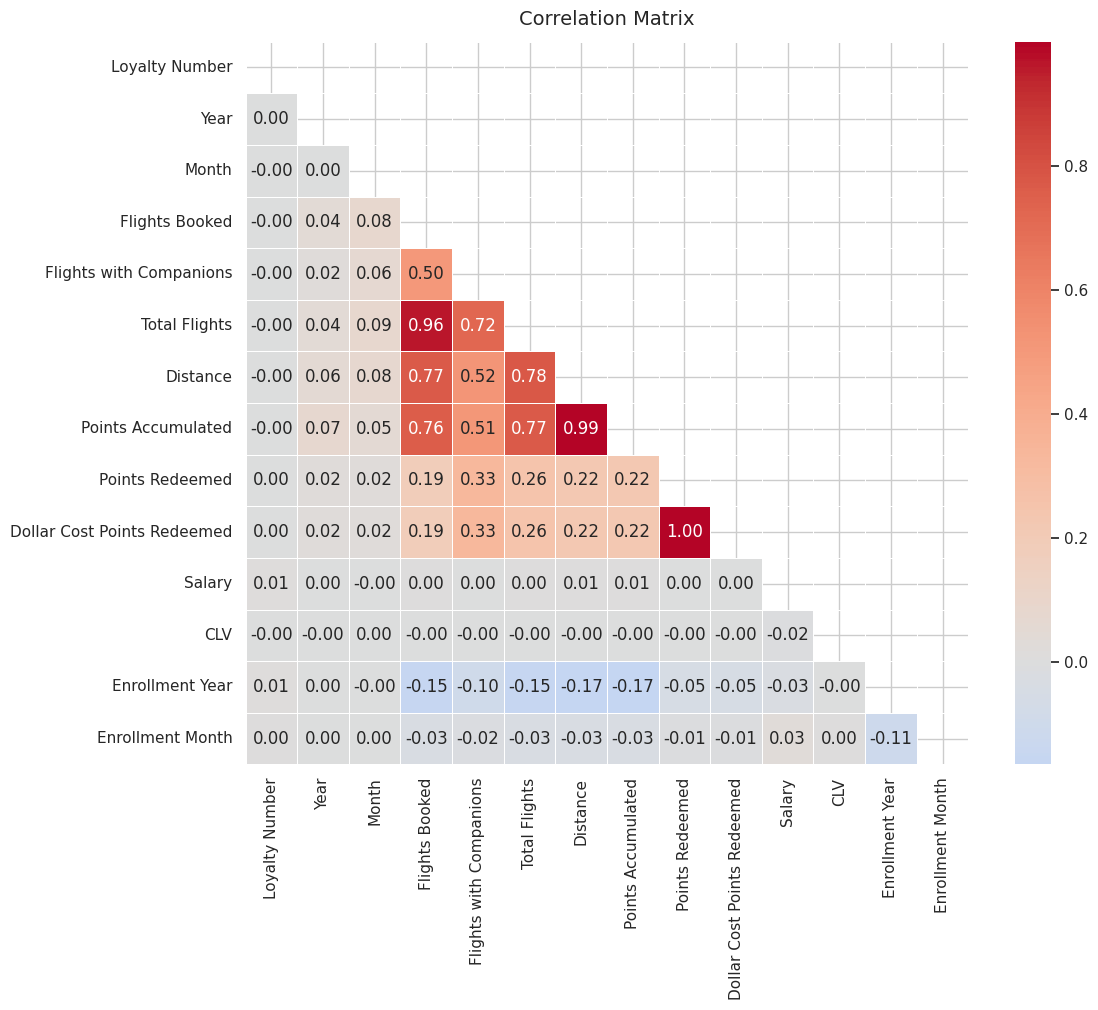

,Var 1,Var 2,r
0,Points Redeemed,Dollar Cost Points Redeemed,1.0000
1,Distance,Points Accumulated,0.9946
2,Flights Booked,Total Flights,0.9613
3,Total Flights,Distance,0.7797
4,Total Flights,Points Accumulated,0.7719
5,Flights Booked,Distance,0.7671
6,Flights Booked,Points Accumulated,0.7600
7,Flights with Companions,Total Flights,0.7207


In [9]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Pairs with correlation > 0.7
high = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 4))
        for i in range(len(corr)) for j in range(i+1, len(corr))
        if abs(corr.iloc[i,j]) > 0.7]
display(pd.DataFrame(high, columns=['Var 1','Var 2','r'])
          .sort_values('r', ascending=False).reset_index(drop=True))

> **Key correlations**
> - `Distance` ↔ `Points Accumulated`: r = 0.99 — points faithfully reflect distance flown.
> - `Points Redeemed` ↔ `Dollar Cost Points Redeemed`: r > 0.99 — redundant variables; keep only one.
> - `Flights Booked` ↔ `Total Flights`: r = 0.96 — `Total Flights` is derivable; can be dropped from models.
>
> **Recommended dimensionality reduction:** remove 2–3 redundant variables with no information loss.

### 2.2 Categorical Variables

── Loyalty Card ──
Loyalty Card
Aurora    10673.0
Nova       8046.0
Star       6742.0

── Education ──
Education
Bachelor                8207.0
Doctor                  7833.0
High School or Below    7707.0
College                 7595.0
Master                  7441.0

── Marital Status ──
Marital Status
Divorced    8201.0
Married     8058.0
Single      7719.0

── Province ──
Province
Quebec                  8161.0
New Brunswick           8154.0
Saskatchewan            8076.0
Manitoba                8067.0
Newfoundland            8025.0
British Columbia        7994.0
Nova Scotia             7983.0
Ontario                 7914.0
Alberta                 7753.0
Prince Edward Island    7704.0
Yukon                   6772.0

── Cancelled ──
Cancelled
True     8132.0
False    7969.0



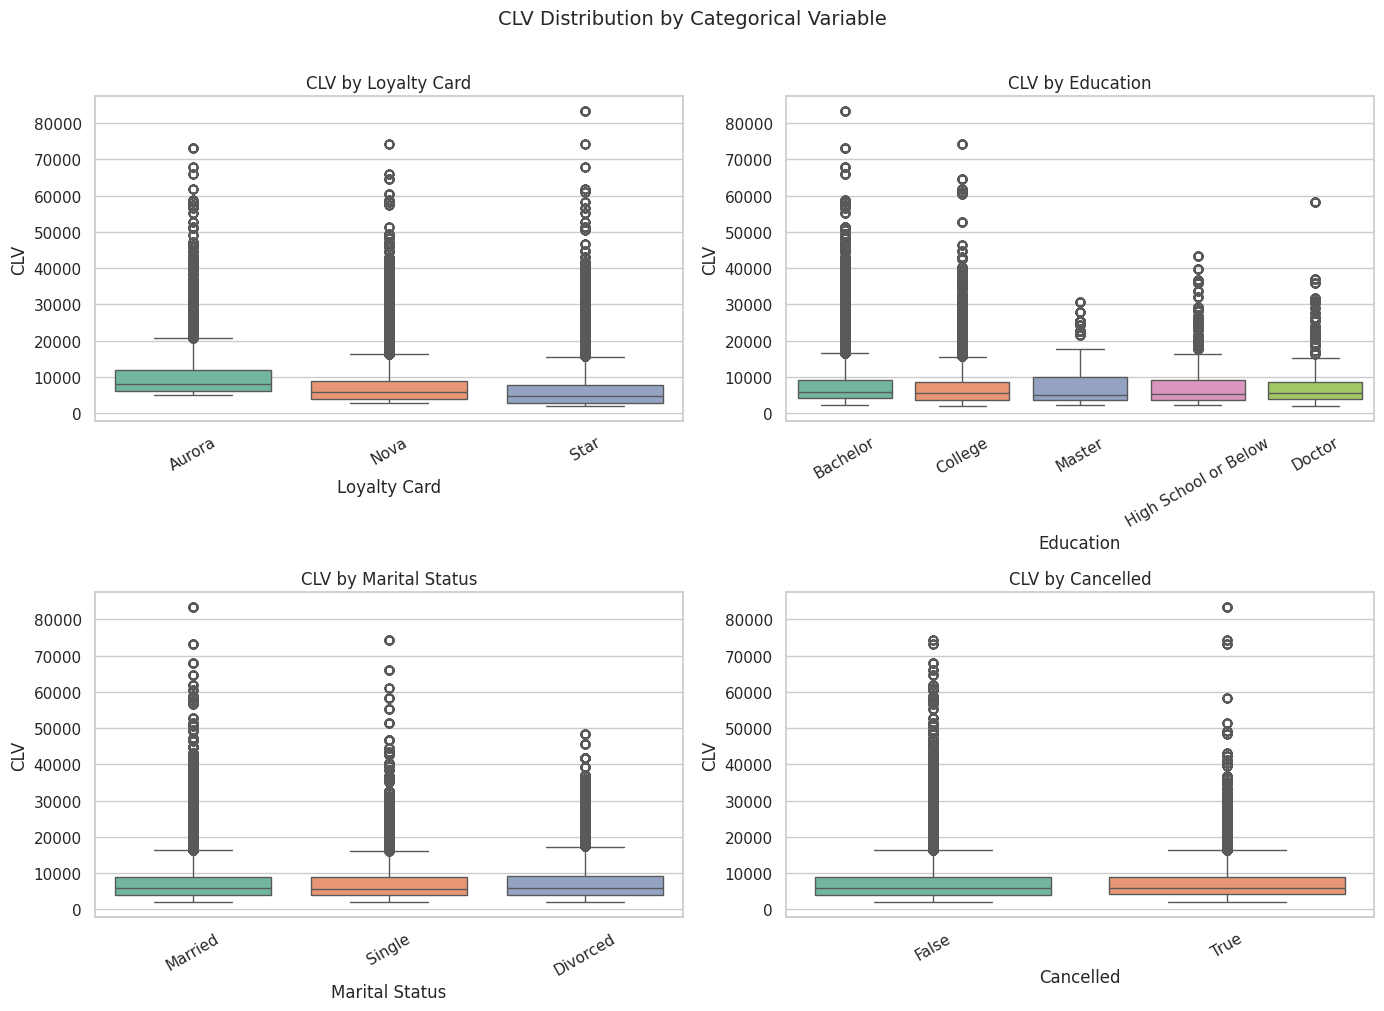

In [10]:
# Mean CLV by category
for col in ['Loyalty Card', 'Education', 'Marital Status', 'Province', 'Cancelled']:
    print(f'── {col} ──')
    print(df.groupby(col)['CLV'].mean().round(0).sort_values(ascending=False).to_string())
    print()

# CLV boxplots by key categorical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flatten(), ['Loyalty Card', 'Education', 'Marital Status', 'Cancelled']):
    sns.boxplot(data=df, x=var, y='CLV', ax=ax, palette='Set2')
    ax.set_title(f'CLV by {var}')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('CLV Distribution by Categorical Variable', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Encoding for models
df['Cancelled_num']    = df['Cancelled'].astype(int)
df['Loyalty_Card_ord'] = df['Loyalty Card'].map({'Star': 1, 'Nova': 2, 'Aurora': 3})

> **Key findings**
> - Members with an **Aurora** card generate **43% more CLV** than Star card holders.
> - **Cancelled** members have an average CLV ~15% lower — a signal of critical churn.
> - `Gender` and `Enrollment Type` show minimal CLV differences — can be excluded from models.
> - **Most valuable profile:** Aurora card · Bachelor's degree · married · active · British Columbia.

---
## 3 · Visualizations

### 3.1 Monthly Booked Flights (Seasonality)

**Objective:** identify demand patterns throughout the year and differences between 2017 and 2018.

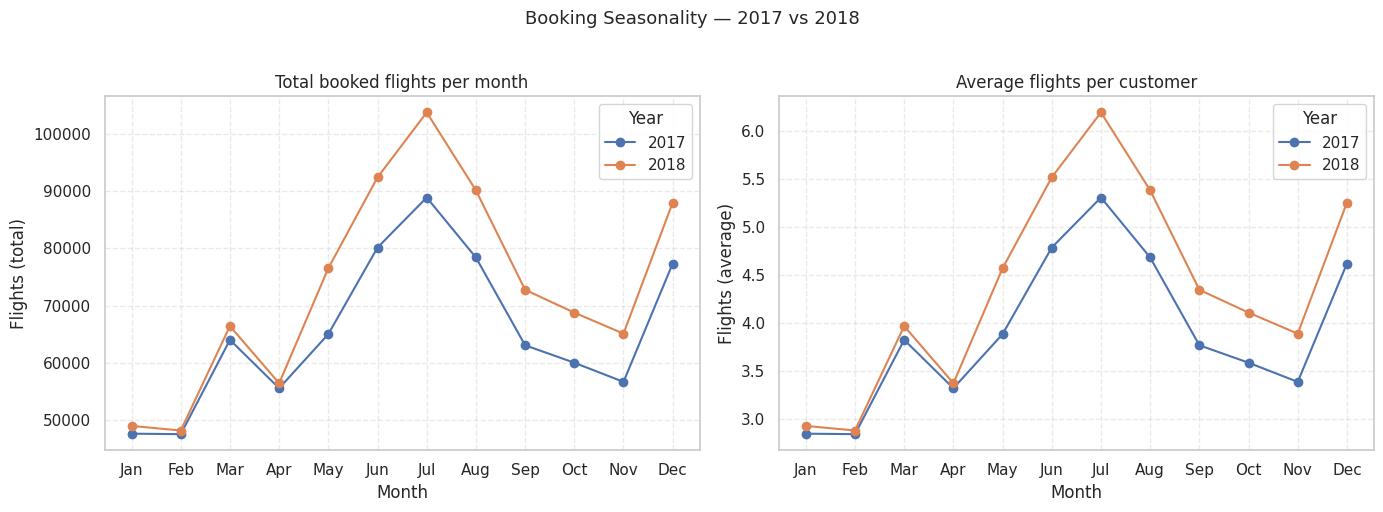

In [11]:
monthly = df.groupby(['Year', 'Month'])['Flights Booked'].agg(['sum', 'mean']).reset_index()
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for year, grp in monthly.groupby('Year'):
    ax1.plot(grp['Month'], grp['sum'],  marker='o', label=str(year))
    ax2.plot(grp['Month'], grp['mean'], marker='o', label=str(year))

for ax, title, ylabel in [
    (ax1, 'Total booked flights per month', 'Flights (total)'),
    (ax2, 'Average flights per customer',   'Flights (average)'),
]:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.legend(title='Year')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Booking Seasonality — 2017 vs 2018', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** clear seasonality with peaks in summer (Jun–Aug) and December.
> In 2018, volume grows from May onward, both in total and per-customer average.
> Low months (Jan–Apr) are the ideal window for **demand-stimulation promotions**.

### 3.2 Distance Flown vs Points Accumulated (by Loyalty Card Tier)

**Objective:** verify points program consistency, detect year-over-year policy changes,
and assess whether accumulation rates differ by card tier.

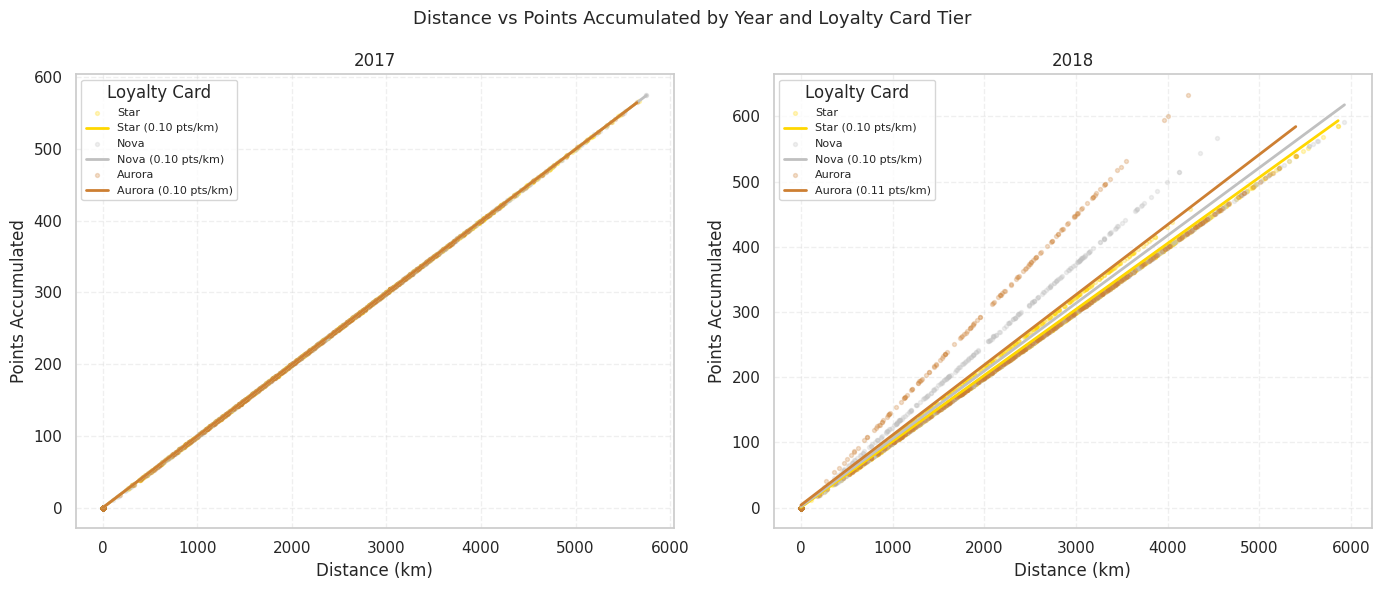

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

card_order = ['Star', 'Nova', 'Aurora']
palette    = {'Star': '#FFD700', 'Nova': '#C0C0C0', 'Aurora': '#CD7F32'}

for ax, year in zip(axes, [2017, 2018]):
    sub = (df[df['Year'] == year]
           .dropna(subset=['Loyalty Card'])
           .sample(5000, random_state=42))

    for card in card_order:
        grp = sub[sub['Loyalty Card'] == card]
        ax.scatter(grp['Distance'], grp['Points Accumulated'],
                   alpha=0.25, s=8, color=palette[card], label=card)

        m, b = np.polyfit(grp['Distance'], grp['Points Accumulated'], 1)
        x_line = np.linspace(grp['Distance'].min(), grp['Distance'].max(), 100)
        ax.plot(x_line, m * x_line + b, color=palette[card], lw=2,
                label=f'{card} ({m:.2f} pts/km)')

    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Points Accumulated')
    ax.legend(fontsize=8, title='Loyalty Card')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Distance vs Points Accumulated by Year and Loyalty Card Tier',
             fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:** near-perfect correlation (r ≈ 0.99) in both years confirms data quality.
> The **slope increased in 2018**, indicating a policy change: more points awarded per km flown.
> Comparing slopes across card tiers reveals whether the program applies a **uniform or tiered
> accumulation rate** — a key variable for segmentation and future CLV models.
> `Year` must be included as a control variable when modeling points accumulated.

### 3.3 Geographic Distribution of Customers

**Objective:** identify provincial concentration and assess program reach.

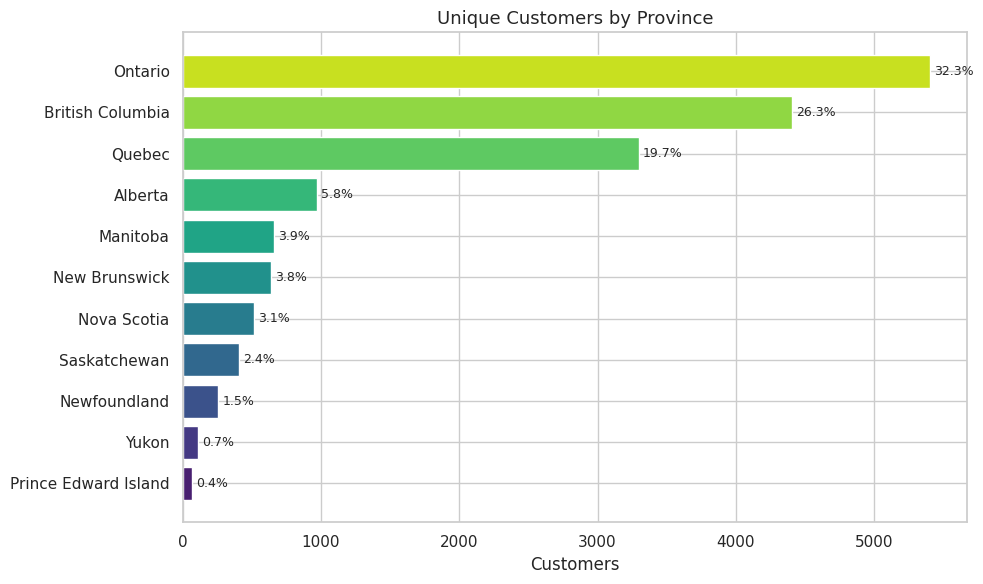

In [13]:
prov  = df.groupby('Province')['Loyalty Number'].nunique().sort_values(ascending=True)
total = prov.sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prov.index, prov.values, color=sns.color_palette('viridis', len(prov)))
for bar, val in zip(bars, prov.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{100*val/total:.1f}%', va='center', fontsize=9)
ax.set_title('Unique Customers by Province', fontsize=13)
ax.set_xlabel('Customers')
plt.tight_layout()
plt.show()

> **Insight:** Ontario (32.3%), British Columbia (26.3%), and Quebec (19.7%) account for **78% of members**.
> For predictive models, low-representation provinces should be grouped as 'Other'.
> Campaigns in Quebec require differentiated linguistic and cultural considerations.

### 3.4 Average Salary by Education Level

**Objective:** validate data coherence and quantify the salary gap by education.

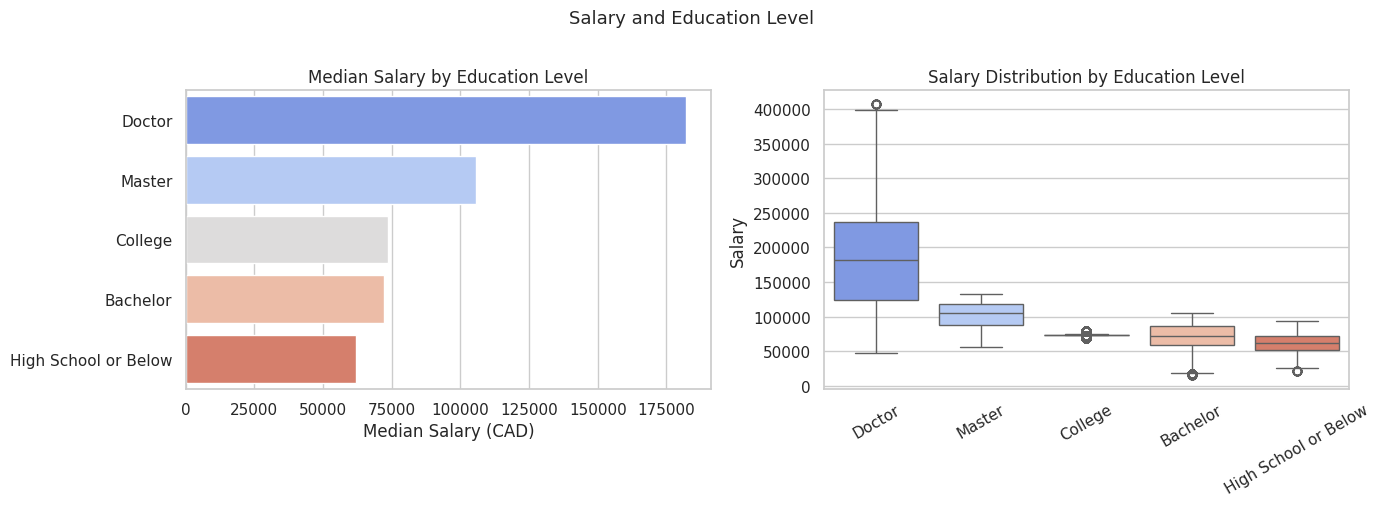

,mean,median,n
Education,,,
Doctor,178609.0,182144.0,17616
Master,103758.0,105487.0,12192
College,73434.0,73458.0,101712
Bachelor,72647.0,72059.0,251400
High School or Below,61229.0,61928.0,18768


In [14]:
edu_stats = (df.groupby('Education')['Salary']
               .agg(mean='mean', median='median', n='count')
               .round(0).sort_values('mean', ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=edu_stats.reset_index(), x='median', y='Education',
            palette='coolwarm', ax=ax1)
ax1.set_title('Median Salary by Education Level')
ax1.set_xlabel('Median Salary (CAD)')
ax1.set_ylabel('')

order = edu_stats.index.tolist()
sns.boxplot(data=df, x='Education', y='Salary', order=order,
            palette='coolwarm', ax=ax2)
ax2.set_title('Salary Distribution by Education Level')
ax2.tick_params(axis='x', rotation=30)
ax2.set_xlabel('')

plt.suptitle('Salary and Education Level', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

display(edu_stats)

> **Insight:** customers with a **Bachelor's degree** have the highest median salary;
> the gap with *High School or Below* exceeds 30%, consistent with socioeconomic reality.
> This validates the salary imputation performed. `Education` is a useful predictor of spending capacity.

### 3.5 Distribution by Loyalty Card Type

**Objective:** assess penetration of each program tier and its relationship with CLV.

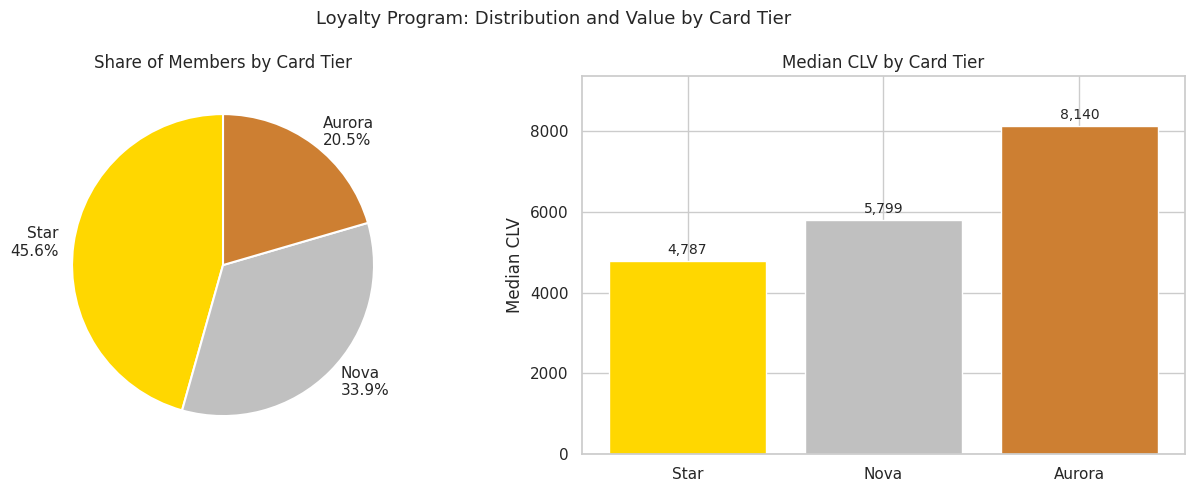

In [15]:
lc      = df.groupby('Loyalty Card')['Loyalty Number'].nunique().reindex(['Star','Nova','Aurora'])
pct     = 100 * lc / lc.sum()
clv_card = df.groupby('Loyalty Card')['CLV'].median().reindex(['Star','Nova','Aurora'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#FFD700', '#C0C0C0', '#CD7F32']

ax1.pie(pct, labels=[f'{k}\n{v:.1f}%' for k, v in pct.items()],
        startangle=90, colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title('Share of Members by Card Tier')

bars2 = ax2.bar(clv_card.index, clv_card.values, color=colors, edgecolor='white')
for bar, val in zip(bars2, clv_card):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 100, f'{val:,.0f}',
             ha='center', va='bottom', fontsize=10)
ax2.set_title('Median CLV by Card Tier')
ax2.set_ylabel('Median CLV')
ax2.set_ylim(0, clv_card.max() * 1.15)

plt.suptitle('Loyalty Program: Distribution and Value by Card Tier', fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:** typical tiered program distribution: Star (45.6%) > Nova (33.9%) > Aurora (20.5%).
> **79.5% are in the two lower tiers** — a major upgrade opportunity.
> Aurora members generate ~43% more CLV than Star members:
> **promoting tier upgrades is the highest-impact lever for profitability**.

### 3.6 Marital Status and Gender

**Objective:** characterize the demographic profile and verify whether biases exist in the sample.

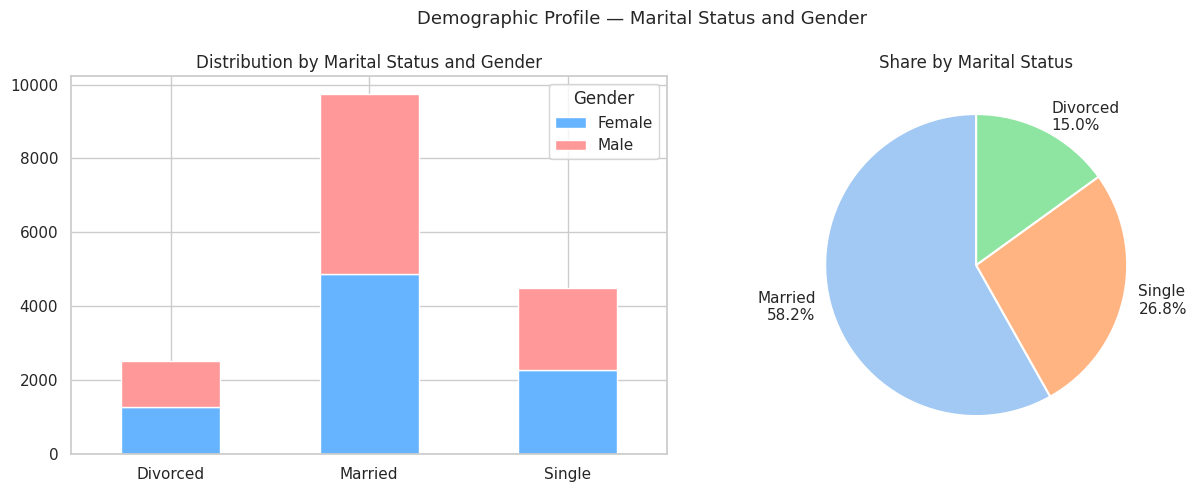

Gender distribution:
Gender
Female    50.2
Male      49.8


In [16]:
df_u = df.drop_duplicates(subset=['Loyalty Number'])

contingency = pd.crosstab(df_u['Marital Status'], df_u['Gender'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

contingency.plot(kind='bar', stacked=True,
                 color=['#66b3ff','#ff9999'], edgecolor='white', ax=ax1)
ax1.set_title('Distribution by Marital Status and Gender')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=0)

ms_counts = df_u['Marital Status'].value_counts()
ax2.pie(ms_counts,
        labels=[f'{k}\n{100*v/ms_counts.sum():.1f}%' for k, v in ms_counts.items()],
        startangle=90, colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Share by Marital Status')

plt.suptitle('Demographic Profile — Marital Status and Gender', fontsize=13)
plt.tight_layout()
plt.show()

print('Gender distribution:')
print((df_u['Gender'].value_counts(normalize=True).round(3) * 100).to_string())

> **Insight:** **58.2% of members are married** and gender is perfectly balanced (~50%).
> No relevant gender bias exists.
> `Gender` can be excluded from predictive models; `Marital Status` does add segmentation value,
> especially combined with `Flights with Companions` to identify family travelers.

### 3.7 Customer Lifetime Value (CLV) Distribution

**Objective:** visualize the shape of the CLV distribution, identify its skewness,
and quantify the high-value segment that the mean obscures.

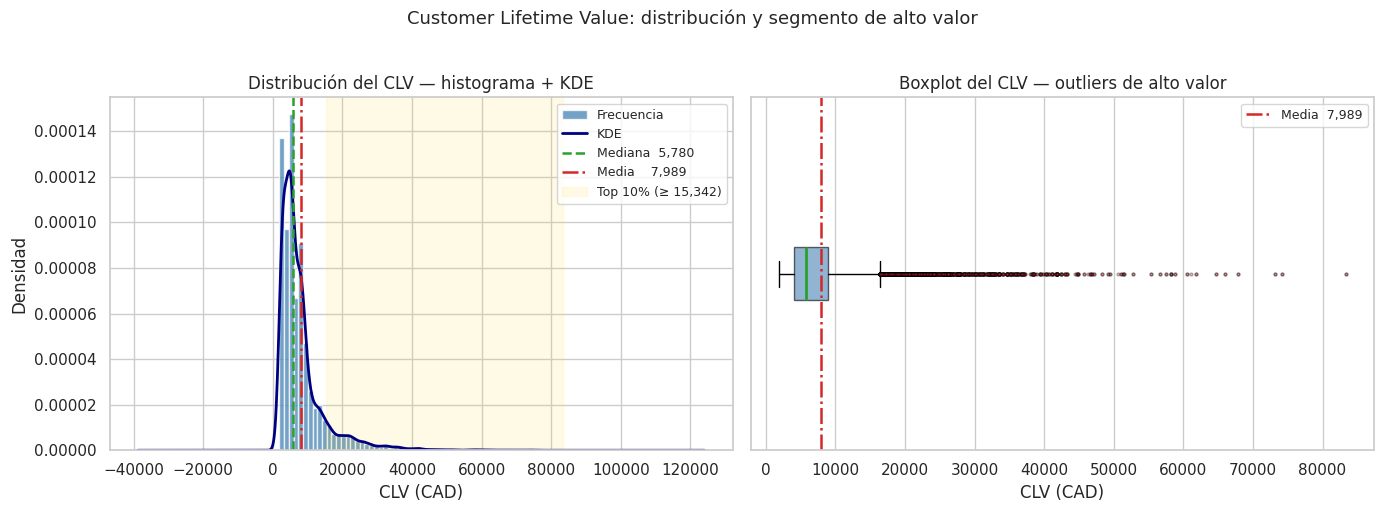

Clientes en top 10% (CLV ≥ 15,342): 1,674 (10.0%)
Diferencia media–mediana: 2,209 CAD (38.2%)


In [17]:
clv = df.drop_duplicates(subset=['Loyalty Number'])['CLV'].dropna()

mediana  = clv.median()
media    = clv.mean()
p90      = clv.quantile(0.90)
alto_val = (clv >= p90).sum()
pct_av   = 100 * alto_val / len(clv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma + KDE ──────────────────────────────────────────────────────
ax = axes[0]
ax.hist(clv, bins=60, color='steelblue', edgecolor='white', alpha=0.75,
        density=True, label='Frecuencia')
clv.plot.kde(ax=ax, color='navy', lw=2, label='KDE')
ax.axvline(mediana, color='#2ca02c', lw=1.8, linestyle='--',
           label=f'Mediana  {mediana:,.0f}')
ax.axvline(media,   color='#d62728', lw=1.8, linestyle='-.',
           label=f'Media    {media:,.0f}')
ax.axvspan(p90, clv.max(), alpha=0.10, color='gold',
           label=f'Top 10% (≥ {p90:,.0f})')
ax.set_title('Distribución del CLV — histograma + KDE', fontsize=12)
ax.set_xlabel('CLV (CAD)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

# ── Boxplot horizontal ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.boxplot(clv, vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='#2ca02c', lw=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.3,
                            markerfacecolor='#d62728'))
ax2.axvline(media, color='#d62728', lw=1.8, linestyle='-.',
            label=f'Media  {media:,.0f}')
ax2.set_title('Boxplot del CLV — outliers de alto valor', fontsize=12)
ax2.set_xlabel('CLV (CAD)')
ax2.set_yticks([])
ax2.legend(fontsize=9)

plt.suptitle('Customer Lifetime Value: distribución y segmento de alto valor',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Clientes en top 10% (CLV ≥ {p90:,.0f}): {alto_val:,} ({pct_av:.1f}%)")
print(f"Diferencia media–mediana: {media - mediana:,.0f} CAD ({100*(media-mediana)/mediana:.1f}%)")

> **Insight:** the CLV distribution is **markedly right-skewed** —
> the mean exceeds the median by ~38%, evidence of a high-value tail.
> The **top 10% of members** disproportionately concentrate program value;
> this segment should receive differentiated treatment in retention and upgrade campaigns.
> The boxplot confirms that outliers are structural (genuine high-value customers),
> not data errors — consistent with the analysis in section 2.1.

---
## 4 · Hypothesis Testing: Booked Flights by Education Level

**Question:** Does the total number of booked flights differ significantly by customer education level?

- **H₀:** means are equal across all education levels.
- **H₁:** at least one education level differs significantly.

Both ANOVA (parametric) and Kruskal-Wallis (non-parametric) are applied as complementary tests.

Total flights statistics by education level:


,count,mean,std,min,25%,50%,75%,max
Education,,,,,,,,
Bachelor,10475.0,98.70,53.53,0.0,59.0,113.0,139.00,237.0
College,4238.0,100.14,53.22,0.0,62.0,113.0,140.00,235.0
Doctor,734.0,100.27,54.88,0.0,56.5,115.0,142.75,203.0
High School or Below,782.0,100.35,53.61,0.0,62.0,115.0,139.00,204.0
Master,508.0,101.01,52.85,0.0,65.0,113.0,140.25,239.0


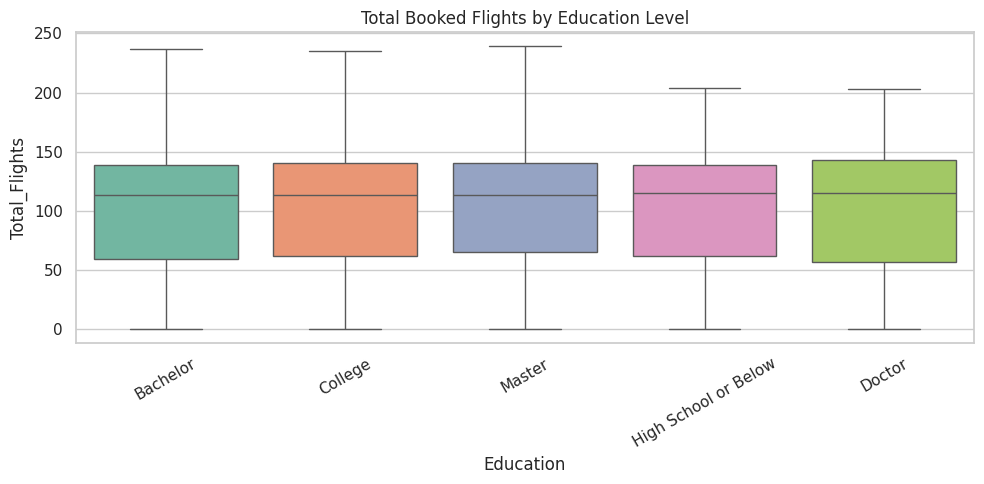

ANOVA          F = 0.8564 | p = 0.4893
Kruskal-Wallis H = 3.6735 | p = 0.4520


In [18]:
# Total flights per customer
fpc = (df.groupby(['Loyalty Number', 'Education'])['Flights Booked']
         .sum().reset_index()
         .rename(columns={'Flights Booked': 'Total_Flights'}))

# Descriptive stats by education level
print('Total flights statistics by education level:')
display(fpc.groupby('Education')['Total_Flights'].describe().round(2))

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=fpc, x='Education', y='Total_Flights', palette='Set2')
plt.title('Total Booked Flights by Education Level')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Statistical tests
groups       = [g['Total_Flights'].values for _, g in fpc.groupby('Education')]
f_stat, p_anova = f_oneway(*groups)
h_stat, p_kw    = kruskal(*groups)

print(f'ANOVA          F = {f_stat:.4f} | p = {p_anova:.4f}')
print(f'Kruskal-Wallis H = {h_stat:.4f} | p = {p_kw:.4f}')

### Results

| Test | Statistic | p-value | Conclusion |
|------|-----------|---------|------------|
| ANOVA | F = 0.8564 | 0.4893 | Not significant |
| Kruskal-Wallis | H = 3.6735 | 0.4520 | Not significant |

> **Conclusion:** with p >> 0.05 on both tests, **there is no statistical evidence** that
> the number of flights differs by education level. Observed means are virtually identical
> (98.7–101.0 flights per customer). `Education` is not a driver of flight activity.
>
> **Practical implication:** campaigns aimed at increasing bookings can be designed without
> segmenting by education. Variables with greater discriminating power are `Loyalty Card`,
> `Province`, and `CLV`.

---
## 5 · Conclusions and Recommendations

### 5.1 Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **75% of members never redeem points** | Benefits program is underutilized — high activation opportunity |
| 2 | **Aurora generates 43% more CLV** than Star | Promoting tier upgrades is the highest-impact profitability lever |
| 3 | **Clear seasonality**: peaks in summer and December | Plan capacity and loyalty campaigns for peak season |
| 4 | **12.35% of members cancelled**, with CLV ~15% below average | Churn model is feasible and necessary for early retention |
| 5 | **Geographic concentration**: ON + BC + QC = 78% | Segment regional campaigns; special personalization for Quebec |
| 6 | **Points policy change in 2018**: higher pts/km slope | Include `Year` as a control variable in points models |
| 7 | **Education level does not predict flights** (p = 0.49) | Booking campaigns can be designed without education segmentation |
| 8 | **Redundant variables identified**: `Total Flights`, `Dollar Cost Points Redeemed` | Reduce dimensionality before modeling |

### 5.2 Next Steps

1. **CLV prediction model:** use `Loyalty Card`, `Province`, `Education`, `Marital Status`,
   `Salary`, and flight activity as features.
2. **Churn model:** binary classifier with `Cancelled` as the target variable.
3. **Customer segmentation:** clustering (K-Means or hierarchical) on activity and profile.
4. **Tier upgrade analysis:** identify the profile of members who upgraded tiers
   to replicate the pattern through targeted campaigns.
5. **A/B experiment:** points activation campaign for the 75% of members who never redeem.